In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_womens_development_index.csv")

df.head()

,Country Name,Country Code,adolescent_fertility,gdp_per_capita,female_labor_force_participation,female_life_expectancy,maternal_mortality,women_in_parliament,female_secondary_enrollment,female_tertiary_enrollment,...,female_life_expectancy_norm,women_in_parliament_norm,female_unemployment_norm,maternal_mortality_norm,adolescent_fertility_norm,education_index,economic_participation_index,health_index,political_representation_index,womens_development_index
0,Finland,FIN,3.095,52834.291675,57.489,84.3,8.0,46.000000,151.367447,123.140877,...,0.886347,0.751020,0.844056,0.992944,0.982809,0.853936,0.759592,0.954033,0.751020,0.829645
1,Iceland,ISL,3.369,82138.789297,70.368,84.3,3.0,47.619048,106.320831,104.202988,...,0.886347,0.777454,0.927243,0.997984,0.981018,0.647533,0.883623,0.955116,0.777454,0.815931
2,Sweden,SWE,1.792,54950.283473,61.685,85.0,4.0,46.418338,143.316437,104.125679,...,0.907338,0.757850,0.807540,0.996976,0.991326,0.770771,0.768192,0.965213,0.757850,0.815507
3,Norway,NOR,1.405,87497.217965,62.371,84.6,1.0,46.153846,116.642189,114.607201,...,0.895343,0.753532,0.918422,1.000000,0.993856,0.712781,0.828024,0.963066,0.753532,0.814351
4,Australia,AUS,6.715,65058.377315,62.576,85.1,2.0,38.410596,131.097336,125.171501,...,0.910337,0.627112,0.915456,0.998992,0.959146,0.792299,0.827854,0.956158,0.627112,0.800856


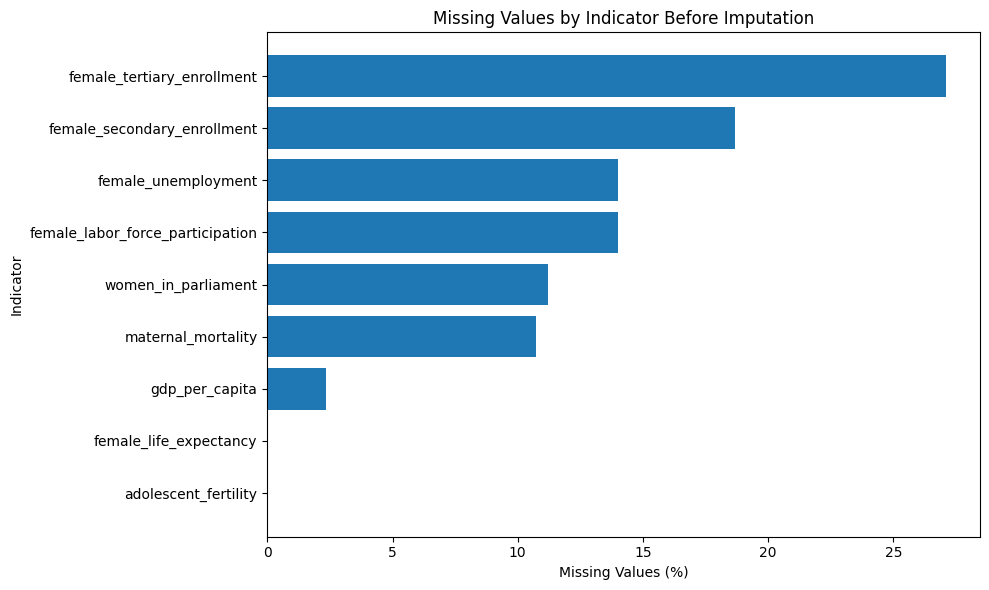

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path("../outputs/Charts").mkdir(parents=True, exist_ok=True)

missing_report = pd.read_csv("../data/processed/world_bank_missing_report.csv")

# Rename the first column to indicator
missing_report = missing_report.rename(columns={
    missing_report.columns[0]: "indicator"
})

missing_chart = missing_report[
    ~missing_report["indicator"].isin(["Country Name", "Country Code"])
].copy()

missing_chart = missing_chart.sort_values("missing_percentage", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    missing_chart["indicator"],
    missing_chart["missing_percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Indicator")
plt.title("Missing Values by Indicator Before Imputation")

plt.tight_layout()
plt.savefig("../outputs/Charts/missing_values_by_indicator.png", dpi=300)
plt.show()

### Missing Values by Indicator

This chart shows the percentage of missing values for each selected World Bank indicator before imputation. Missing value analysis was carried out to understand the quality and completeness of the dataset before constructing the composite index.

Indicators with higher missing percentages required more careful treatment because excessive imputation could reduce the reliability of the final index. Countries with too many missing values were removed, while remaining missing values were filled using median imputation.

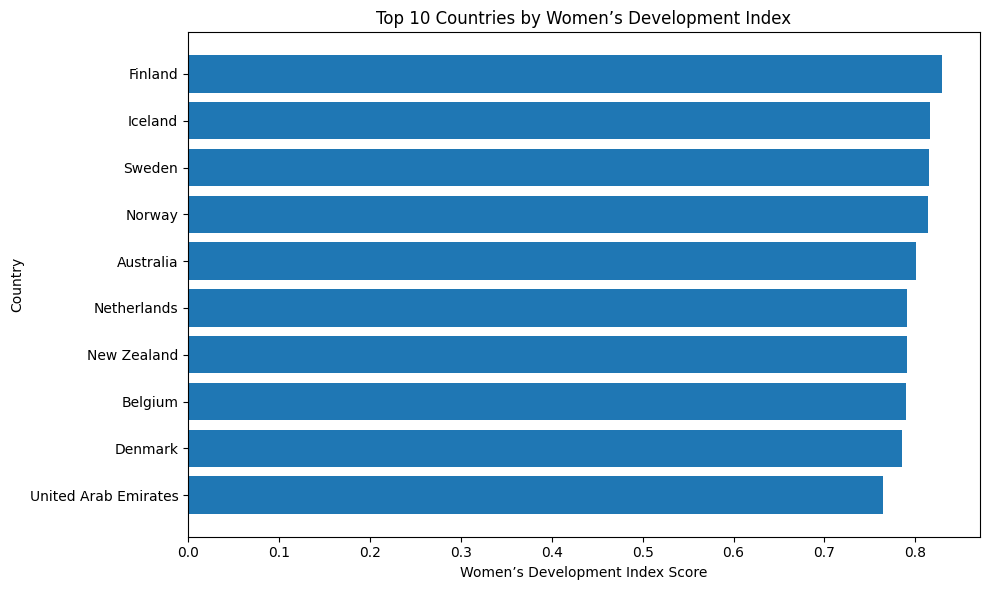

In [24]:
top_10 = df.sort_values("womens_development_index", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10["Country Name"], top_10["womens_development_index"])
plt.xlabel("Women’s Development Index Score")
plt.ylabel("Country")
plt.title("Top 10 Countries by Women’s Development Index")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/Charts/top_10_wdi.png", dpi=300)
plt.show()

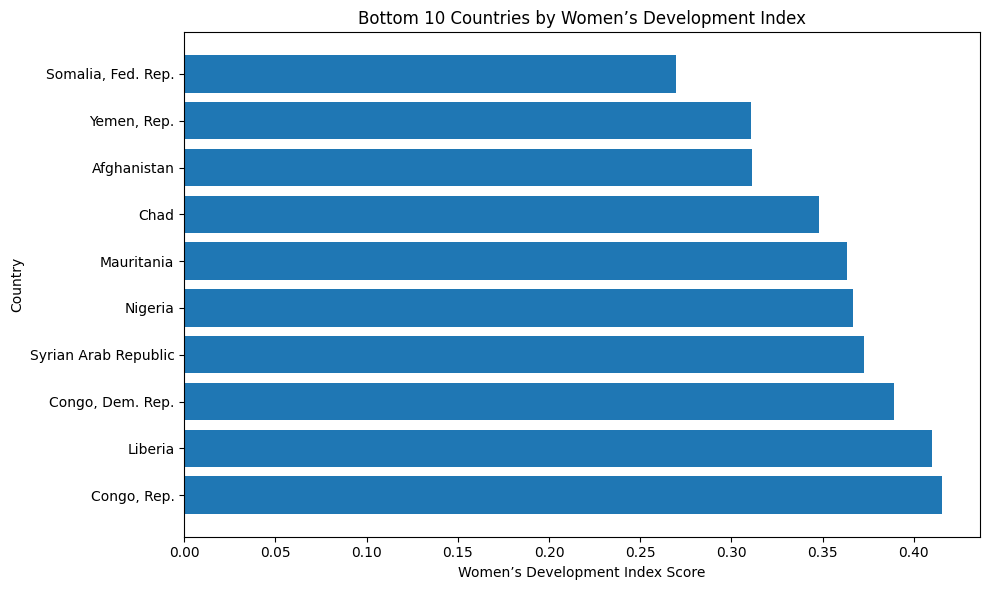

In [25]:
bottom_10 = df.sort_values("womens_development_index", ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.barh(bottom_10["Country Name"], bottom_10["womens_development_index"])
plt.xlabel("Women’s Development Index Score")
plt.ylabel("Country")
plt.title("Bottom 10 Countries by Women’s Development Index")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/Charts/bottom_10_wdi.png", dpi=300)
plt.show()

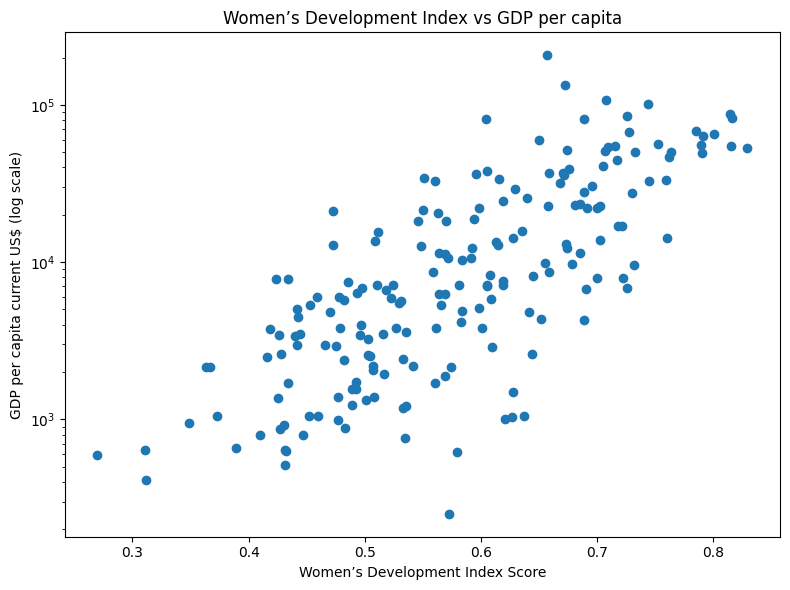

In [26]:
df_plot = df[df["gdp_per_capita"] > 0].copy()

plt.figure(figsize=(8, 6))
plt.scatter(df_plot["womens_development_index"], df_plot["gdp_per_capita"])
plt.yscale("log")
plt.xlabel("Women’s Development Index Score")
plt.ylabel("GDP per capita current US$ (log scale)")
plt.title("Women’s Development Index vs GDP per capita")
plt.tight_layout()
plt.savefig("../outputs/Charts/wdi_vs_gdp_log.png", dpi=300)
plt.show()

In [27]:
correlation = df["womens_development_index"].corr(df["gdp_per_capita"])
correlation

np.float64(0.5835132625553949)

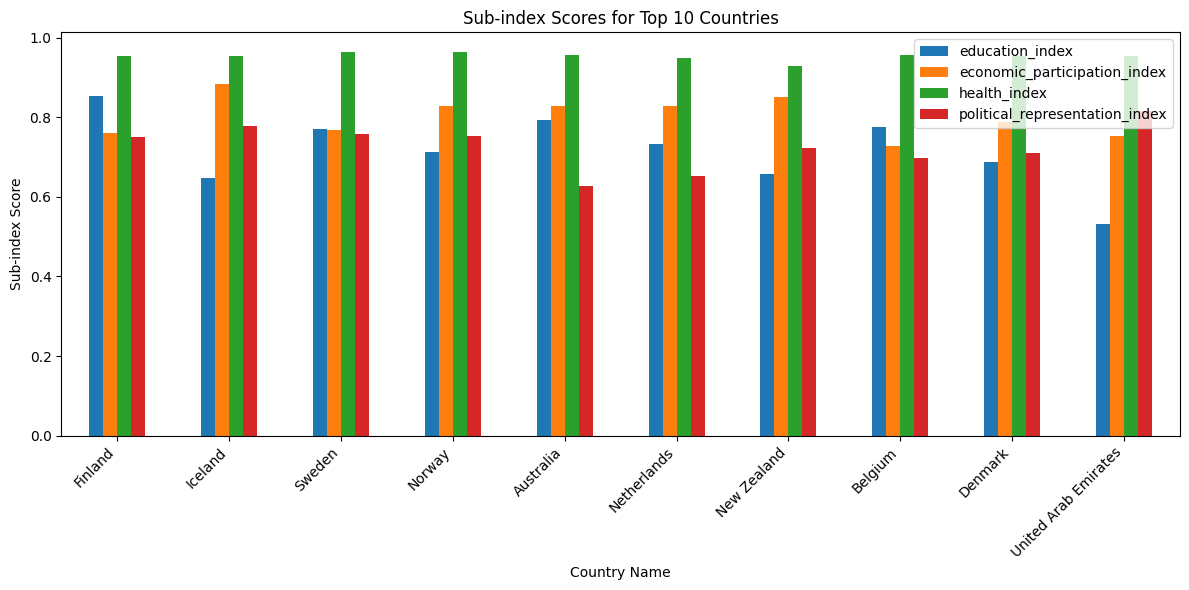

In [28]:
top_10_sub = df.sort_values("womens_development_index", ascending=False).head(10)

sub_cols = [
    "education_index",
    "economic_participation_index",
    "health_index",
    "political_representation_index"
]

top_10_sub.set_index("Country Name")[sub_cols].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Sub-index Score")
plt.title("Sub-index Scores for Top 10 Countries")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/Charts/top_10_subindices.png", dpi=300)
plt.show()

In [29]:
df[df["Country Name"].str.contains("United States", case=False, na=False)][
    [
        "Country Name",
        "womens_development_index",
        "education_index",
        "economic_participation_index",
        "health_index",
        "political_representation_index",
        "gdp_per_capita"
    ]
]


df[df["Country Name"].isin(["United States", "Finland"])][
    [
        "Country Name",
        "womens_development_index",
        "education_index",
        "economic_participation_index",
        "health_index",
        "political_representation_index",
        "gdp_per_capita"
    ]
]

,Country Name,womens_development_index,education_index,economic_participation_index,health_index,political_representation_index,gdp_per_capita
0,Finland,0.829645,0.853936,0.759592,0.954033,0.751020,52834.291675
38,United States,0.688856,0.594247,0.791148,0.897124,0.472906,81032.262118
